In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import IsolationForest
import pickle


In [18]:
csv_path = r"C:/Users/acer/OneDrive/Desktop/ai lab project/data/expenses_pkr.csv"
df = pd.read_csv(csv_path)
df.head()

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20/09/2018 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,103.50,Expense,PKR
1,20/09/2018 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,207.00,Expense,PKR
2,19/09/2018,Saving Bank account 1,subscription,Netflix,1 month subscription,686.55,Expense,PKR
3,17/09/2018 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,65.55,Expense,PKR
4,16/09/2018 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,865.95,Expense,PKR


In [46]:
df.columns = df.columns.str.strip().str.lower()


In [19]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)

# Check if any dates couldn't be parsed
print("Unparsed Dates:", df['Date'].isna().sum())

# Drop rows where date failed to parse
df = df.dropna(subset=['Date'])

df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

df.head()


Unparsed Dates: 1158


,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency,Day,Month,Year
0,2018-09-20 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,103.50,Expense,PKR,20,9,2018
1,2018-09-20 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,207.00,Expense,PKR,20,9,2018
3,2018-09-17 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,65.55,Expense,PKR,17,9,2018
4,2018-09-16 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,865.95,Expense,PKR,16,9,2018
5,2018-09-15 06:34:17,Credit Card,subscription,Tata Sky,Permanent Residence - Tata Play recharge,690.00,Expense,PKR,15,9,2018


In [20]:
category_summary = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)
category_summary

Category
Salary                       8.446561e+06
Fixed Deposit                1.552500e+06
Saving Bank account 1        5.271551e+05
Transportation               4.935777e+05
Maturity amount              4.913007e+05
Household                    4.339258e+05
Other                        2.965503e+05
Money transfer               2.829793e+05
subscription                 2.067705e+05
Food                         1.915368e+05
Share Market                 1.673250e+05
Health                       1.453235e+05
Family                       1.410298e+05
Tax refund                   9.014850e+04
Tourism                      7.110053e+04
Gift                         6.210345e+04
Apparel                      5.070403e+04
Investment                   4.238670e+04
Petty cash                   3.163650e+04
maid                         2.594400e+04
Festivals                    1.859895e+04
Interest                     1.833330e+04
Beauty                       1.058115e+04
Recurring Deposit        

In [21]:
monthly_summary = df.groupby(['Year','Month'])['Amount'].sum()
monthly_summary

Year  Month
2015  1        1.529730e+04
      2        1.949802e+05
      3        2.667395e+05
      4        1.831847e+05
      5        2.378258e+05
      6        1.692467e+05
      7        1.747667e+05
      8        2.253299e+05
      9        1.828638e+05
      10       2.020803e+05
      11       1.804178e+05
      12       2.818340e+05
2016  1        3.628503e+05
      2        2.118852e+05
      3        2.479032e+05
      4        1.823030e+05
      5        2.219661e+05
      6        2.031012e+05
      7        1.894637e+05
      8        2.340790e+05
      9        2.092632e+05
      10       2.156360e+05
      11       3.037932e+05
      12       2.583933e+05
2017  1        2.456090e+05
      2        2.777492e+05
      3        2.593606e+05
      4        2.320631e+05
      5        2.178226e+05
      6        9.361075e+05
      7        6.927255e+05
      8        5.034437e+05
      9        2.495489e+05
      10       5.516374e+04
      11       3.764237e+05
      12

In [22]:
X = df[['Day','Month','Year']]
y = df['Amount']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae, rmse

(18434.65663483171, np.float64(52033.65559578974))

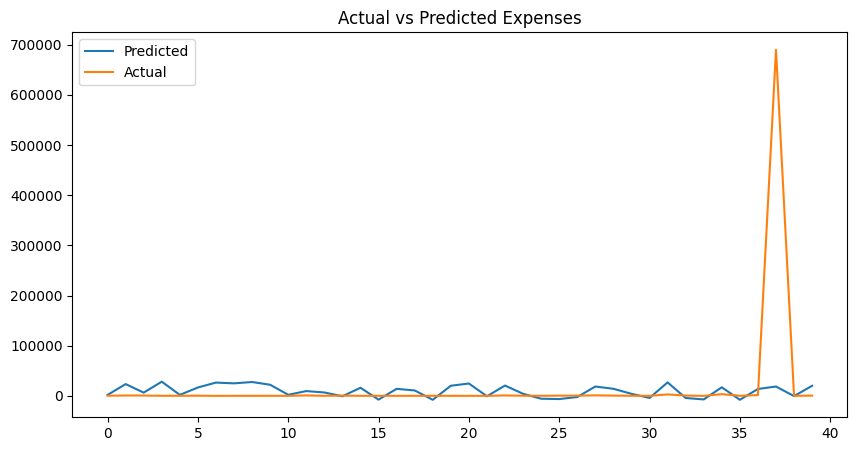

In [24]:
plt.figure(figsize=(10,5))
plt.plot(pred[:40], label='Predicted')
plt.plot(y_test.values[:40], label='Actual')
plt.title('Actual vs Predicted Expenses')
plt.legend()
plt.show()

In [25]:
iso = IsolationForest(contamination=0.05, random_state=42)
df['Anomaly'] = iso.fit_predict(df[['Amount']])
anomalies = df[df['Anomaly'] == -1]
anomalies

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency,Day,Month,Year,Anomaly
33,2018-08-31 09:27:28,Saving Bank account 1,Salary,NaN,From workplace,242379.75,Income,PKR,31,8,2018,-1
102,2018-07-31 18:01:20,Saving Bank account 1,Money transfer,Home,NaN,103500.00,Expense,PKR,31,7,2018,-1
105,2018-07-31 09:05:17,Saving Bank account 1,Salary,NaN,From workplace,242379.75,Income,PKR,31,7,2018,-1
121,2018-07-26 13:44:31,Saving Bank account 1,Tax refund,NaN,NaN,23391.00,Income,PKR,26,7,2018,-1
195,2018-06-30 08:44:48,Saving Bank account 1,Salary,NaN,From workplace,224670.90,Income,PKR,30,6,2018,-1
...,...,...,...,...,...,...,...,...,...,...,...,...
2200,2015-05-31 12:02:40,Saving Bank account 1,Salary,NaN,From workplace,165113.55,Income,PKR,31,5,2015,-1
2201,2015-05-31 12:02:40,Saving Bank account 1,Money transfer,NaN,NaN,34500.00,Expense,PKR,31,5,2015,-1
2202,2015-05-17 17:57:12,Saving Bank account 1,Transportation,Taxi,BR to mumbai,20700.00,Expense,PKR,17,5,2015,-1
2232,2015-04-28 15:44:31,Saving Bank account 1,Salary,NaN,From workplace,170105.70,Income,PKR,28,4,2015,-1


In [26]:
# Generate next 7 dates (future prediction)
future_7 = pd.date_range(start=df['Date'].max(), periods=8, freq='D')[1:]

future_7_df = pd.DataFrame({
    'Date': future_7,
    'Day': future_7.day,
    'Month': future_7.month,
    'Year': future_7.year
})

# Predict using the trained model
future_7_df['Predicted_Amount'] = model.predict(
    future_7_df[['Day', 'Month', 'Year']]
)

future_7_df


,Date,Day,Month,Year,Predicted_Amount
0,2018-09-21 12:04:08,21,9,2018,6656.556816
1,2018-09-22 12:04:08,22,9,2018,8475.172806
2,2018-09-23 12:04:08,23,9,2018,10293.788796
3,2018-09-24 12:04:08,24,9,2018,12112.404786
4,2018-09-25 12:04:08,25,9,2018,13931.020776
5,2018-09-26 12:04:08,26,9,2018,15749.636766
6,2018-09-27 12:04:08,27,9,2018,17568.252756


In [27]:
# Generate next 30 dates
future_30 = pd.date_range(start=df['Date'].max(), periods=31, freq='D')[1:]

future_30_df = pd.DataFrame({
    'Date': future_30,
    'Day': future_30.day,
    'Month': future_30.month,
    'Year': future_30.year
})

future_30_df['Predicted_Amount'] = model.predict(
    future_30_df[['Day', 'Month', 'Year']]
)

future_30_df


,Date,Day,Month,Year,Predicted_Amount
0,2018-09-21 12:04:08,21,9,2018,6656.556816
1,2018-09-22 12:04:08,22,9,2018,8475.172806
2,2018-09-23 12:04:08,23,9,2018,10293.788796
3,2018-09-24 12:04:08,24,9,2018,12112.404786
4,2018-09-25 12:04:08,25,9,2018,13931.020776
5,2018-09-26 12:04:08,26,9,2018,15749.636766
6,2018-09-27 12:04:08,27,9,2018,17568.252756
7,2018-09-28 12:04:08,28,9,2018,19386.868746
8,2018-09-29 12:04:08,29,9,2018,21205.484736
9,2018-09-30 12:04:08,30,9,2018,23024.100726


In [31]:
# --- Basic Preprocessing ---
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.sort_values(by='Date')

# Remove missing or invalid rows
df = df.dropna(subset=['Date', 'Amount'])
df['Amount'] = df['Amount'].astype(float)


In [32]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.03, random_state=42)
df['anomaly_score'] = iso.fit_predict(df[['Amount']])

# Mark anomalies clearly
df['Anomaly'] = df['anomaly_score'].apply(lambda x: "Yes" if x == -1 else "No")

df.drop(columns=['anomaly_score'], inplace=True)

print(df['Anomaly'].value_counts())


Anomaly
No     1263
Yes      40
Name: count, dtype: int64


In [33]:
category_summary = df[df['Income/Expense'] == 'Expense'].groupby('Category')['Amount'].sum().sort_values(ascending=False)

category_summary


Category
Transportation         493577.7000
Household              433925.7510
Money transfer         282979.3500
subscription           206770.5405
Food                   191536.7550
Health                 145323.4875
Family                 141029.7900
Other                  127172.5200
Tourism                 71100.5325
Gift                    62103.4500
Apparel                 50704.0290
Investment              42386.7000
maid                    25944.0000
Festivals               18598.9500
Beauty                  10581.1500
Culture                  6525.1920
Recurring Deposit        3450.0000
Self-development         3277.5000
Grooming                 1104.0000
Education                1083.3000
Social Life              1028.1000
water (jar /tanker)       138.0000
Name: Amount, dtype: float64

C:\Users\acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


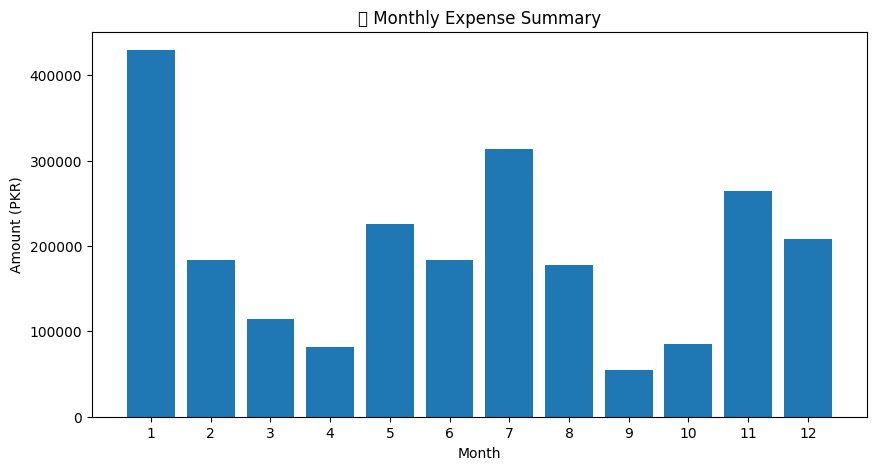

In [40]:
# 1) Filter only actual expenses
expense_df = df[df['Income/Expense'] == 'Expense']

# 2) Create monthly summary
monthly_summary = expense_df.groupby('Month')['Amount'].sum().reset_index()

# 3) Rename column for clarity
monthly_summary.rename(columns={'Amount': 'Total_Expense_PKR'}, inplace=True)

# 4) Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(monthly_summary['Month'], monthly_summary['Total_Expense_PKR'])
plt.title("📊 Monthly Expense Summary")
plt.ylabel("Amount (PKR)")
plt.xlabel("Month")
plt.xticks(monthly_summary['Month'])
plt.show()


C:\Users\acer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129534 (\N{RECEIPT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


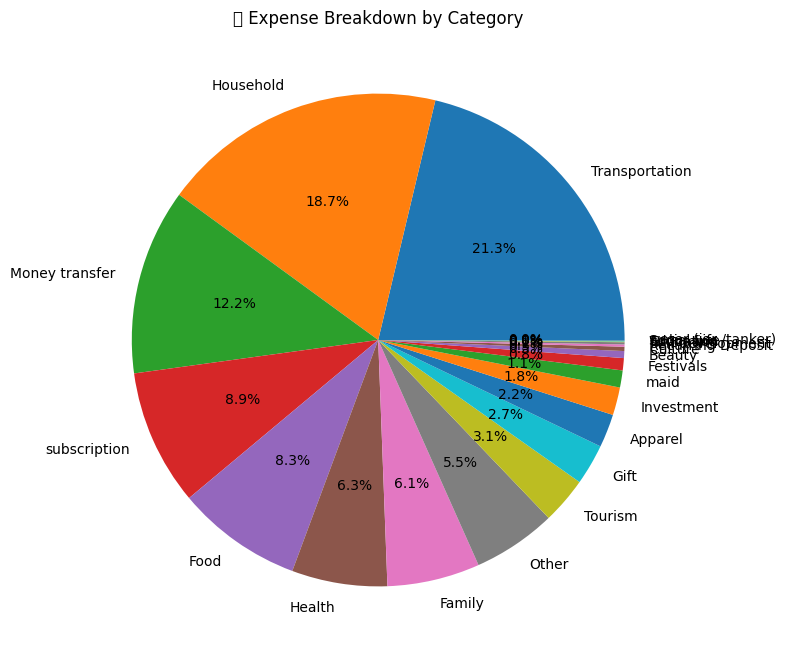

In [35]:
plt.figure(figsize=(8, 8))
category_summary.plot(kind='pie', autopct='%1.1f%%')
plt.title("🧾 Expense Breakdown by Category")
plt.ylabel("")
plt.show()


In [36]:
processed_path = "processed_expenses.csv"
df.to_csv(processed_path, index=False)
processed_path


'processed_expenses.csv'

In [37]:
import pickle

with open("expense_predictor_model.pkl", "wb") as f:
    pickle.dump(model, f)  # 'model' must be your regression model


In [ ]:
def generate_insights(df, monthly_summary, category_summary):

    # Highest expense month
    highest_month_index = monthly_summary['Total_Expense_PKR'].idxmax()
    highest_month = monthly_summary.loc[highest_month_index, 'Month']

    # Highest expense category
    highest_category = category_summary.idxmax()

    # Anomalies count
    anomalies_count = df[df['Anomaly'] == 'Yes'].shape[0]

    print(" :) Insights:")
    print(f"• Highest expense month: {highest_month}")
    print(f"• Highest spending category: {highest_category}")
    print(f"• Total anomalies detected: {anomalies_count}")


In [45]:
generate_insights(df, monthly_summary, category_summary)


 Insights:
• Highest expense month: 1
• Highest spending category: Transportation
• Total anomalies detected: 40


In [29]:
model_path = r"C:/Users/acer/OneDrive/Desktop/ai lab project/model/expense_model.pkl"
with open(model_path, 'wb') as f:
    pickle.dump(model, f)
"Model saved successfully!"

'Model saved successfully!'

In [30]:
df.columns


Index(['Date', 'Mode', 'Category', 'Subcategory', 'Note', 'Amount',
       'Income/Expense', 'Currency', 'Day', 'Month', 'Year', 'Anomaly'],
      dtype='object')

In [39]:
df['Income/Expense'].unique()


array(['Expense', 'Income', 'Transfer-Out'], dtype=object)